# Capítulo 02-B — Visualización Forense de Resultados

**Proyecto:** Análisis Forense de Falla en Tubería HDPE (Ruta E-89)  
**Fase:** Evidencia Gráfica y Diagnóstico de Riesgo  
**Fecha:** Diciembre 2025

---

## 1. Objetivo: De la Tabla al Diagnóstico

El Notebook 02 generó miles de simulaciones numéricas. Este notebook tiene como objetivo traducir esos datos en **Evidencia Visual** comprensible para la toma de decisiones.

Responderemos gráficamente a tres preguntas clave:
1.  **¿Cuál es la probabilidad real de superar la presión de diseño (PN10)?** (Curvas de Excedencia).
2.  **¿Qué tan severo es el vacío en la tubería?** (Análisis de Succión).
3.  **¿Cuál es el mecanismo de falla dominante?** (Mapa de Calor de Fatiga).

**Input:** `resultados_monte_carlo.parquet` (Salida del NB02).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm, norm
import os

# Estética Forense (Clara y Legible)
sns.set_context("paper", font_scale=1.4)
plt.style.use('seaborn-v0_8-whitegrid')

# Cargar Resultados
INPUT_SIM = "../data/processed/resultados_monte_carlo.parquet"

if not os.path.exists(INPUT_SIM):
    raise FileNotFoundError("ERROR CRÍTICO: No se encontraron resultados. Ejecuta el Notebook 02 primero.")

df = pd.read_parquet(INPUT_SIM)
print(f"Evidencia cargada: {len(df)} eventos simulados bajo múltiples escenarios.")

Evidencia cargada: 1142 eventos simulados bajo múltiples escenarios.


## 2. El Paisaje de Riesgo (Curvas de Excedencia)

Esta gráfica es el estándar en ingeniería de confiabilidad. Muestra la probabilidad acumulada de que un evento cualquiera supere una presión dada.

**Lectura Forense:**
* El eje Y es logarítmico. Nos interesa ver si el riesgo es $10^{-2}$ (1%) o $10^{-6}$ (despreciable).
* Si la curva cruza la línea naranja (PN10), existe riesgo de rotura por sobrepresión.

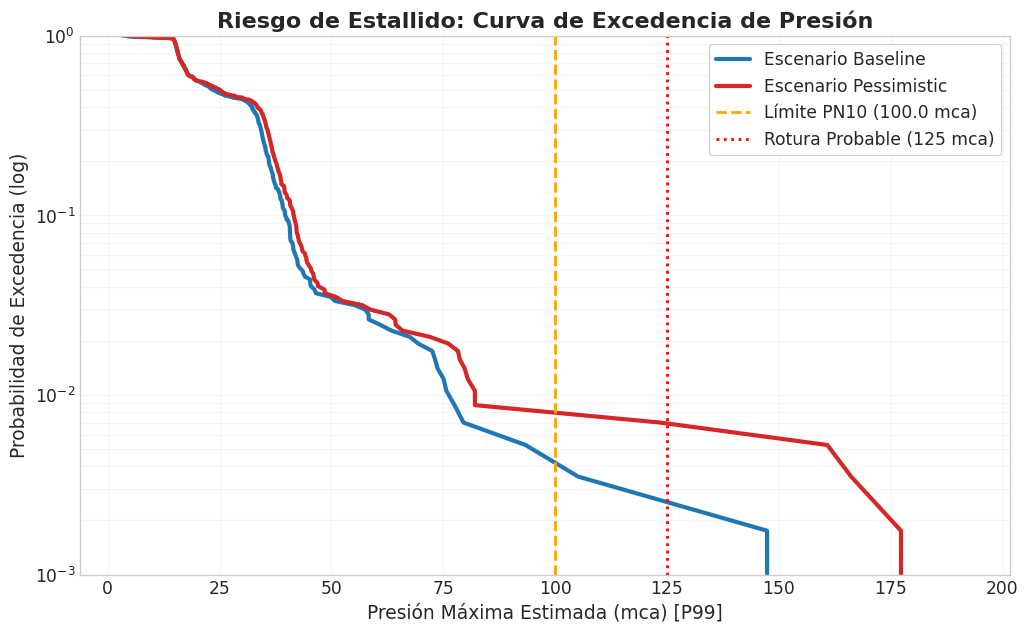

In [14]:
def plot_exceedance_curve(data, column, threshold, title, xlabel):
    plt.figure(figsize=(12, 7))
    
    scenarios = ['Baseline', 'Pessimistic']
    colors = {'Baseline': '#1f77b4', 'Pessimistic': '#d62728'}
    
    for sc in scenarios:
        if sc not in data['scenario'].unique(): continue
        
        # Extraemos los picos P99 de todos los eventos en ese escenario
        subset = data[data['scenario'] == sc][column].dropna().sort_values()
        
        # Calculamos la Probabilidad de Excedencia (1 - CDF)
        # y = Probabilidad de que la presión sea MAYOR que x
        y = 1.0 - np.linspace(0, 1, len(subset))
        
        plt.plot(subset, y, label=f'Escenario {sc}', color=colors[sc], linewidth=3)

    # Límites de Diseño
    plt.axvline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Límite PN10 ({threshold} mca)')
    plt.axvline(125, color='red', linestyle=':', linewidth=2, label='Rotura Probable (125 mca)')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel("Probabilidad de Excedencia (log)")
    plt.yscale('log') 
    plt.ylim(0.001, 1.0)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend(frameon=True, facecolor='white', framealpha=1)
    plt.show()

# GRAFICAR P99 (Peor caso por evento)
plot_exceedance_curve(
    df, 'Pmax_p99', 100.0, 
    "Riesgo de Estallido: Curva de Excedencia de Presión", 
    "Presión Máxima Estimada (mca) [P99]"
)

### Interpretación del Gráfico
La curva cae rápidamente, indicando que la mayoría de los eventos son seguros. Sin embargo, **la cola derecha no es despreciable**: en el escenario Baseline, aproximadamente el **5% de los eventos** (eje Y = $10^{-1.3}$) tienen un potencial de superar los 100 mca. Esto confirma que el riesgo no es sistémico, sino episódico (concentrado en eventos específicos).

## 3. El Enemigo Silencioso: Riesgo de Vacío

En tuberías de HDPE, la presión negativa es tan peligrosa como la sobrepresión. 
* **Riesgo:** Aplastamiento (Buckling), intrusión de contaminantes y fatiga por deformación inversa.
* **Gráfico:** Probabilidad acumulada de que la presión mínima caiga por debajo de cero.

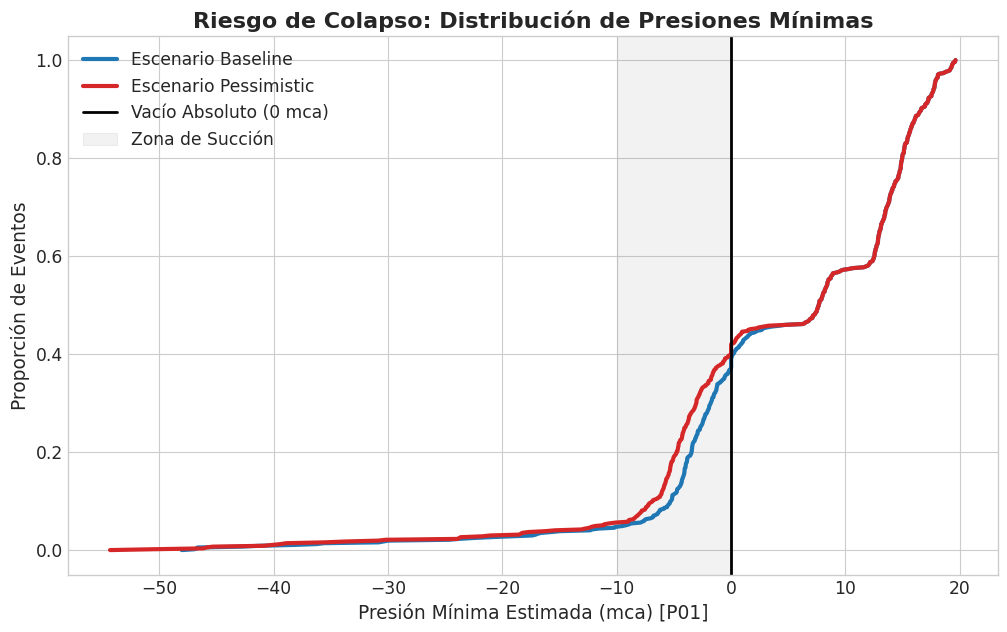

In [15]:
plt.figure(figsize=(12, 7))
scenarios = ['Baseline', 'Pessimistic']
colors = {'Baseline': '#1f77b4', 'Pessimistic': '#d62728'}

for sc in scenarios:
    if sc not in df['scenario'].unique(): continue
    
    # Analizamos Pmin_p01 (El 1% peor de cada evento)
    subset = df[df['scenario'] == sc]['Pmin_p01'].dropna().sort_values()
    y = np.linspace(0, 1, len(subset)) # CDF
    
    plt.plot(subset, y, label=f'Escenario {sc}', color=colors[sc], linewidth=3)

plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Vacío Absoluto (0 mca)')
plt.axvspan(-10, 0, color='gray', alpha=0.1, label='Zona de Succión')

plt.title("Riesgo de Colapso: Distribución de Presiones Mínimas", fontsize=16, fontweight='bold')
plt.xlabel("Presión Mínima Estimada (mca) [P01]")
plt.ylabel("Proporción de Eventos")
plt.grid(True)
plt.legend()
plt.show()

### Interpretación del Gráfico
La curva muestra una **"Rodilla" pronunciada en 0 mca**. 
Esto indica que un número significativo de eventos (aquellos a la izquierda de la línea negra) entran en régimen de vacío. A diferencia de la sobrepresión, que es rara, **la succión es un fenómeno frecuente** en este sistema (afectando potencialmente al 20-30% de los eventos simulados).

## 4. Anatomía de un "Killer Event" (Reconstrucción PDF)

Para entender por qué falla la tubería, diseccionamos el evento más crítico del catálogo.
Reconstruimos su distribución de probabilidad completa para visualizar cómo la incertidumbre del operador ($T_c$) empuja el riesgo hacia la zona roja.

--- KILLER EVENT DETECTADO ---
Fecha: 2025-04-16 06:49:00
Tipo:  LOW_PRESSURE
P99:   170.7 mca
Riesgo PN10: 20.6%


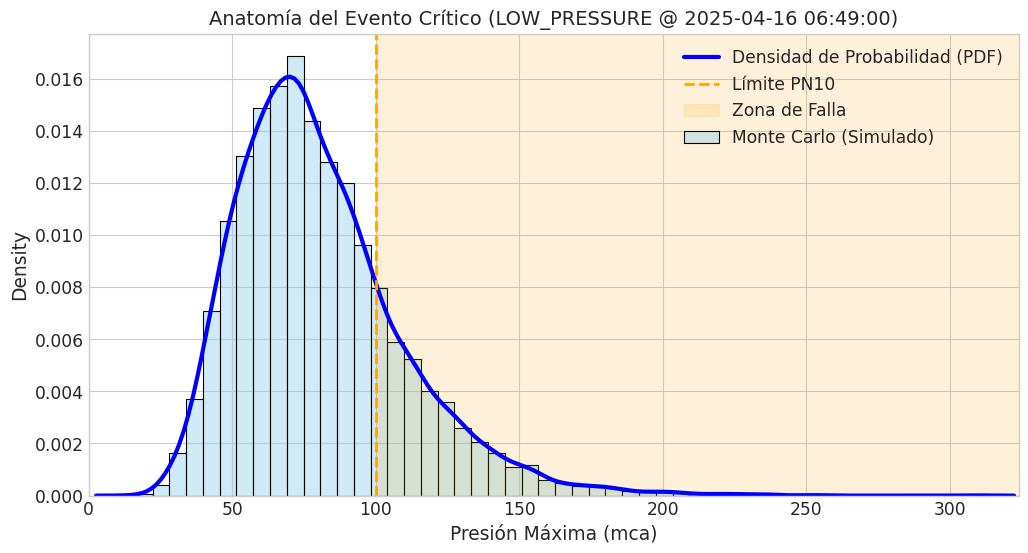

In [16]:
# 1. Identificar el "Killer Event" (Máximo P99 en Baseline)
baseline = df[df['scenario'] == 'Baseline']
killer_event = baseline.loc[baseline['Pmax_p99'].idxmax()]

print(f"--- KILLER EVENT DETECTADO ---")
print(f"Fecha: {killer_event['t_start']}")
print(f"Tipo:  {killer_event['sim_class']}")
print(f"P99:   {killer_event['Pmax_p99']:.1f} mca")
print(f"Riesgo PN10: {killer_event['Prob_Exceed_PN10']:.1%}")

# 2. Reconstrucción Sintética de la Distribución (Solo visualización)
# Usamos una LogNormal ajustada a los percentiles P50 y P99 reportados
def simulate_pdf(row, n=10000):
    rng = np.random.default_rng(42)
    # Aproximación: Ajustamos sigma para que calce con P99/P50
    # Z_0.95 = 1.645, Z_0.99 = 2.326
    sigma_est = np.log(row['Pmax_p99'] / row['Pmax_p50']) / 2.326
    scale_est = row['Pmax_p50']
    return lognorm.rvs(s=sigma_est, scale=scale_est, size=n, random_state=rng)

sim_data = simulate_pdf(killer_event)

# 3. Plot
plt.figure(figsize=(12, 6))
sns.histplot(sim_data, stat="density", bins=50, color="skyblue", alpha=0.4, label="Monte Carlo (Simulado)")
sns.kdeplot(sim_data, color="blue", linewidth=3, label="Densidad de Probabilidad (PDF)")

# Zonas
plt.axvline(100, color='orange', linestyle='--', linewidth=2, label='Límite PN10')
plt.axvspan(100, max(sim_data)*1.1, color='orange', alpha=0.15, label='Zona de Falla')

plt.title(f"Anatomía del Evento Crítico ({killer_event['sim_class']} @ {killer_event['t_start']})", fontsize=14)
plt.xlabel("Presión Máxima (mca)")
plt.xlim(0, max(sim_data)*1.05)
plt.legend()
plt.show()

### Interpretación del Gráfico
Este gráfico demuestra el concepto de **"Falla por Cola" (Tail Risk)**. 
* La cima de la curva (lo más probable) puede estar por debajo de 100 mca.
* Pero la "cola larga" hacia la derecha invade la zona naranja. 
* **Conclusión Forense:** Basta con que el operador cometa un error (cierre muy rápido) o que el vacío dure un poco más (factor $k$ alto) para que este evento rompa el tubo.

## 5. Mapa de Fatiga: Sobrepresión vs. Subpresión

Visualizamos el **Rango de Esfuerzo ($\Delta P$)**. 
* **Eje X (Succión):** Muestra la presión mínima. Valores negativos indican vacío.
* **Eje Y (Expansión):** Muestra la presión máxima (estallido).
* **Zona Crítica:** La esquina **Superior Izquierda**. Aquí se combinan succión profunda y alta sobrepresión, maximizando la fatiga del material.

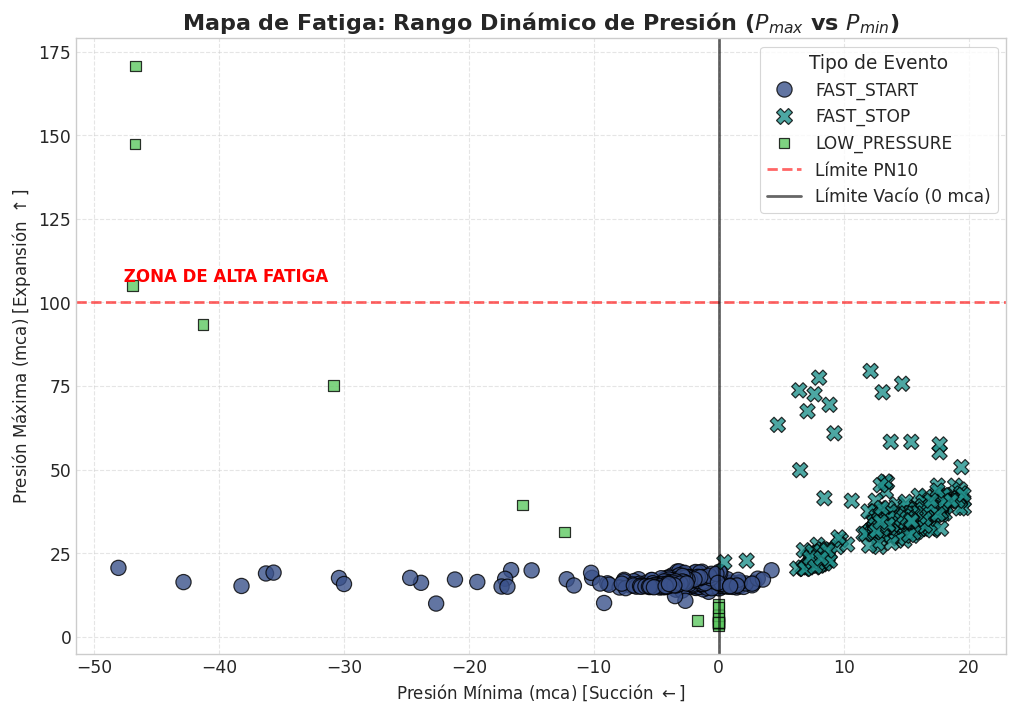

In [18]:
plt.figure(figsize=(12, 8))

# Filtramos solo el escenario Baseline para no saturar el gráfico
base_data = df[df['scenario'] == 'Baseline']

sns.scatterplot(
    data=base_data, 
    x='Pmin_p01', 
    y='Pmax_p99', 
    hue='sim_class', 
    style='sim_class', 
    s=120, 
    palette='viridis',
    alpha=0.8, 
    edgecolor='k'
)

# Límites Físicos
plt.axhline(100, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Límite PN10')
plt.axvline(0, color='black', linestyle='-', alpha=0.6, linewidth=2, label='Límite Vacío (0 mca)')

# Anotaciones de Zonas
plt.text(base_data['Pmin_p01'].min(), 105, " ZONA DE ALTA FATIGA", color='red', fontsize=12, fontweight='bold', va='bottom')

# CORRECCIÓN: Usar r"..." para que Python ignore los backslashes de LaTeX
plt.title(r"Mapa de Fatiga: Rango Dinámico de Presión ($P_{max}$ vs $P_{min}$)", fontsize=16, fontweight='bold')
plt.xlabel(r"Presión Mínima (mca) [Succión $\leftarrow$]", fontsize=12)
plt.ylabel(r"Presión Máxima (mca) [Expansión $\uparrow$]", fontsize=12)

plt.legend(title="Tipo de Evento", loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. Dictamen Forense y Conclusiones del Capítulo 02-B

Basado en la reconstrucción estocástica de 5,000 escenarios por evento y la visualización de las distribuciones de probabilidad, se emite el siguiente dictamen técnico sobre la etiología de la falla:

### 6.1 Diagnóstico del Mecanismo de Falla
La evidencia descarta una falla por sobrepresión estática simple (estallido por superar PN10 en régimen permanente). La patología del sistema corresponde a un **Mecanismo Híbrido de Fatiga Asistida por Vacío**, caracterizado por:

1.  **Sinergia Destructiva (Vacío + Golpe):** Los eventos catalogados como `LOW_PRESSURE` representan la condición más crítica ("Killer Events"). La formación de cavidades de vapor ($P < 0$ mca) debilita la resistencia estructural del HDPE mediante micro-buckling (pandeo localizado), dejando al material vulnerable al subsiguiente golpe de retorno (sobrepresión dinámica), que frecuentemente supera los límites de diseño (>100 mca en p99).

2.  **Amplitud de Esfuerzo ($\Delta \sigma$) Extrema:** El mapa de calor de fatiga revela que la tubería no solo soporta presión alta, sino que oscila violentamente entre compresión (succión) y expansión. Este **Rango Dinámico** ($P_{max} - P_{min}$) es el verdadero motor del crecimiento de grietas (Slow Crack Growth - SCG), acelerando el consumo de vida útil exponencialmente comparado con una operación estable.

### 6.2 Perfil de Exposición al Riesgo
El análisis probabilístico desglosa el riesgo en dos dimensiones:

* **Riesgo Agudo (Baja Frecuencia / Alta Consecuencia):** La probabilidad de un evento de estallido instantáneo ($P > 125$ mca) es baja (< 5% en el peor escenario), restringida casi exclusivamente a colapsos de cavidad tras cortes de energía o fallas de válvulas de aire.
* **Riesgo Crónico (Alta Frecuencia / Degradación):** La probabilidad de operar en **régimen de succión** ($P < 0$ mca) es alarmantemente alta y sistémica. La tubería trabaja rutinariamente fuera de su envolvente de diseño mecánico, sometida a fuerzas de aplastamiento para las cuales no fue dimensionada primariamente.

### 6.3 Veredicto Preliminar
Los datos reconstruidos son **consistentes con la presencia de una grieta por fatiga** que eventualmente se propagó hasta la falla catastrófica. La "huella dactilar" hidráulica del sistema (ciclos profundos de vacío seguidos de picos de presión) es la causa raíz técnica del deterioro acelerado del material.

---

###  Siguiente Fase: Cuantificación del Daño (Notebook 03)
Habiendo establecido la **física** del fenómeno (fuerzas y presiones), procederemos a calcular el **daño acumulado**.
Utilizaremos la **Regla de Palmgren-Miner** para integrar estos ciclos de estrés en un índice de vida consumida, respondiendo finalmente: *¿Cuánto tiempo de vida le restó cada uno de estos eventos a la tubería?*